In [1]:
from utils import *

In [2]:
EJ=8.9
EC=2.5
EL=0.5
g_strength = 0.3

E_osc = 3

qubit_level = 8
osc_level = 50

In [3]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
# plot_specturum(qbt, osc, hilbertspace)

In [4]:
# sweep_resonator_frequency_for_ge_gf_gh_detunning(EJ=8.9,
#                                         EC=2.5,
#                                         EL=0.5,
#                                         flux = 0,
#                                         g_strength = 0.3)

In [13]:
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )
# w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)], product_to_dressed[(0,1)])/2+transition_frequency(hilbertspace,product_to_dressed[(3,0)], product_to_dressed[(3,1)])/2




amp = 0.002
def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *amp * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.03
decay_term = np.sqrt(kappa)*a

tot_time = 1000
tlist = np.linspace(0, tot_time, tot_time*2)

results = []
for i in range(4):
    temp = solve_with_mcsolve(
        H = H_with_drive,
        state0 = qutip.basis(hilbertspace.dimension, product_to_dressed[i,0]),
        tlist = tlist,
        options = qutip.Options(store_states = True,nsteps = 1000, num_cpus = 12),
        c_ops = [decay_term],
        ntraj = 50
    )
    results.append(temp)

10.0%. Run time: 982.65s. Est. time left: 00:02:27:23
20.0%. Run time: 1004.59s. Est. time left: 00:01:06:58
30.0%. Run time: 2000.33s. Est. time left: 00:01:17:47
40.0%. Run time: 2058.46s. Est. time left: 00:00:51:27
50.0%. Run time: 3050.73s. Est. time left: 00:00:50:50
60.0%. Run time: 3103.45s. Est. time left: 00:00:34:28
70.0%. Run time: 3172.83s. Est. time left: 00:00:22:39
80.0%. Run time: 4130.69s. Est. time left: 00:00:17:12
90.0%. Run time: 4216.62s. Est. time left: 00:00:07:48
100.0%. Run time: 4741.25s. Est. time left: 00:00:00:00
Total run time: 4741.28s
10.0%. Run time: 1071.50s. Est. time left: 00:02:40:43
20.0%. Run time: 1095.54s. Est. time left: 00:01:13:02
30.0%. Run time: 2123.17s. Est. time left: 00:01:22:34
40.0%. Run time: 2176.20s. Est. time left: 00:00:54:24


In [8]:
dir(results[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'col_times',
 'col_which',
 'expect',
 'ntraj',
 'num_collapse',
 'num_expect',
 'options',
 'seeds',
 'solver',
 'states',
 'times']

In [7]:


# existing_chunk_num = 0
# for i in range(4):
#     existing_chunk_num = pack_mcsolve_chunks(H = H_with_drive,
#                     state0 = qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
#                     tlist = tlist,
#                     c_ops  = [decay_term],
#                     ntraj = 1000,
#                     existing_chunk_num = existing_chunk_num)

# def pack_pkl_files_to_zip(zip_filename="mcsolve_input.zip"):
#     # Create a new ZIP file
#     with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         # Loop through all files in the current directory
#         for filename in os.listdir('.'):
#             # Check if the file is a .pkl file with an integer name
#             name, ext = os.path.splitext(filename)
#             if ext == '.pkl' and name.isdigit():
#                 # Add the file to the ZIP
#                 zipf.write(filename)
#                 # Delete the .pkl file
#                 os.remove(filename)
                
# pack_pkl_files_to_zip()

 /home/jiakai/.local/lib/python3.10/site-packages/jax/_src/array.py: 363

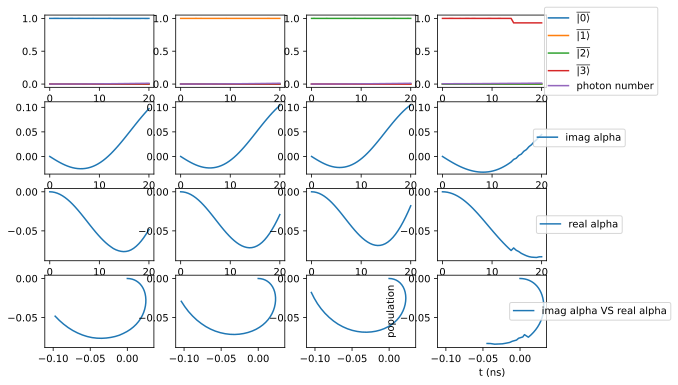

In [6]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

In [ ]:
import qutip as qt

final_qubit_states = []
for initial_state in [0,1,2,3]:
    final_state = results[initial_state].states[-1]
    if final_state.type != 'oper':
        final_state = qt.ket2dm(qutip.Qobj(final_state))
    rho_product = qt.Qobj(dims = [[qubit_level,osc_level],[qubit_level,osc_level]])
    for (ql, ol), dressed_level in product_to_dressed.items():
        qubit_state = qt.basis(qubit_level, ql)
        osc_state = qt.basis(osc_level, ol)
        product_state = qt.tensor(qubit_state, osc_state)
        rho_product += product_state * product_state.dag() * final_state.data[dressed_level, dressed_level]
    qubit_rho = rho_product.ptrace(0)
    final_qubit_states.append(qubit_rho)
